# 1. On/Off Score Heatmap

This notebook visualises the ranked on- and off-morphology scores produced by buscar for each phenotypic state in the MitoCheck dataset.

For each phenotypic state, genes are ranked by their combined on/off score (rank 1 = lowest score) and shown as three colour-coded horizontal strips:

| Strip | Description |
|---|---|
| **Proportion** | Fraction of the gene's cells that display the target phenotype |
| **On score** (log1p-scaled) | Distance between the morphological feature distributions of the reference and treated cell populations |
| **Off score** (raw) | Morphological features unaffected in the reference that become affected after perturbation |

Two sets of plots are produced:
- **Original** — rankings computed from real experimental profiles
- **Shuffled** (null baseline) — rankings computed after randomly permuting feature values, used to assess whether the original signal exceeds chance level

In [5]:
suppressPackageStartupMessages({
    library(arrow)
    library(dplyr)
    library(tidyr)
    library(ggplot2)
    library(pheatmap)
    library(viridisLite)
    library(stringr)
    library(stats)
    library(grid)
    library(gridExtra)
})

options(warn = -1)

In [6]:
truncate_palette <- function(palette_fun, min_val = 0.15, max_val = 1.0, n = 256) {
  vals <- seq(min_val, max_val, length.out = n)
  palette_fun(n)[pmax(1, pmin(n, round(vals * n)))]
}

sig_stars <- function(p) {
  if (is.na(p)) return('n.s.')
  if (p < 0.001) return('***')
  if (p < 0.01) return('**')
  if (p < 0.05) return('*')
  'n.s.'
}

In [7]:
# setting result dir
results_dir <- normalizePath('../results/moa_analysis', mustWork = TRUE)

# setting output
output_dir <- normalizePath(file.path(getwd(), 'all-plots', 'heatmap'), mustWork = FALSE)
dir.create(output_dir, recursive = TRUE, showWarnings = FALSE)

In [8]:
# loadding in moa results
moa_results_df <- read_parquet(file.path(results_dir, 'original_mitocheck_moa_analysis_results.parquet')) %>% as_tibble()
shuffled_moa_results_df <- read_parquet(file.path(results_dir, 'shuffled_mitocheck_moa_analysis_results.parquet')) %>% as_tibble()

# rerank treatment to remove duplicate ranks (nulls ranked last)
moa_results_df <- moa_results_df %>%
  arrange(ref_profile, is.na(on_score), on_score, is.na(off_score), off_score, treatment) %>%
  group_by(ref_profile) %>%
  mutate(rank = row_number()) %>%
  ungroup()

head(moa_results_df)

rank,ref_profile,treatment,on_score,off_score,proportion
<int>,<chr>,<chr>,<dbl>,<dbl>,<dbl>
1,ADCCM,RGR,1.833659e-14,0,0.43055556
2,ADCCM,OGG1,1.136868e-13,0,0.04255319
3,ADCCM,CDK4,2.148890e+02,0,0.00000000
4,ADCCM,ENSG00000175216,2.164150e+02,0,0.00000000
5,ADCCM,CDKL5,2.197899e+02,0,0.00000000
6,ADCCM,LCK,2.241264e+02,0,0.00000000


In [9]:
prepare_df <- function(results_df) {
  results_df %>%
    as.data.frame() %>%
    filter(!is.na(on_score), !is.na(off_score))
}

df <- prepare_df(moa_results_df)
shuf_df <- prepare_df(shuffled_moa_results_df)

profiles <- sort(unique(df$ref_profile))
n_profiles <- length(profiles)

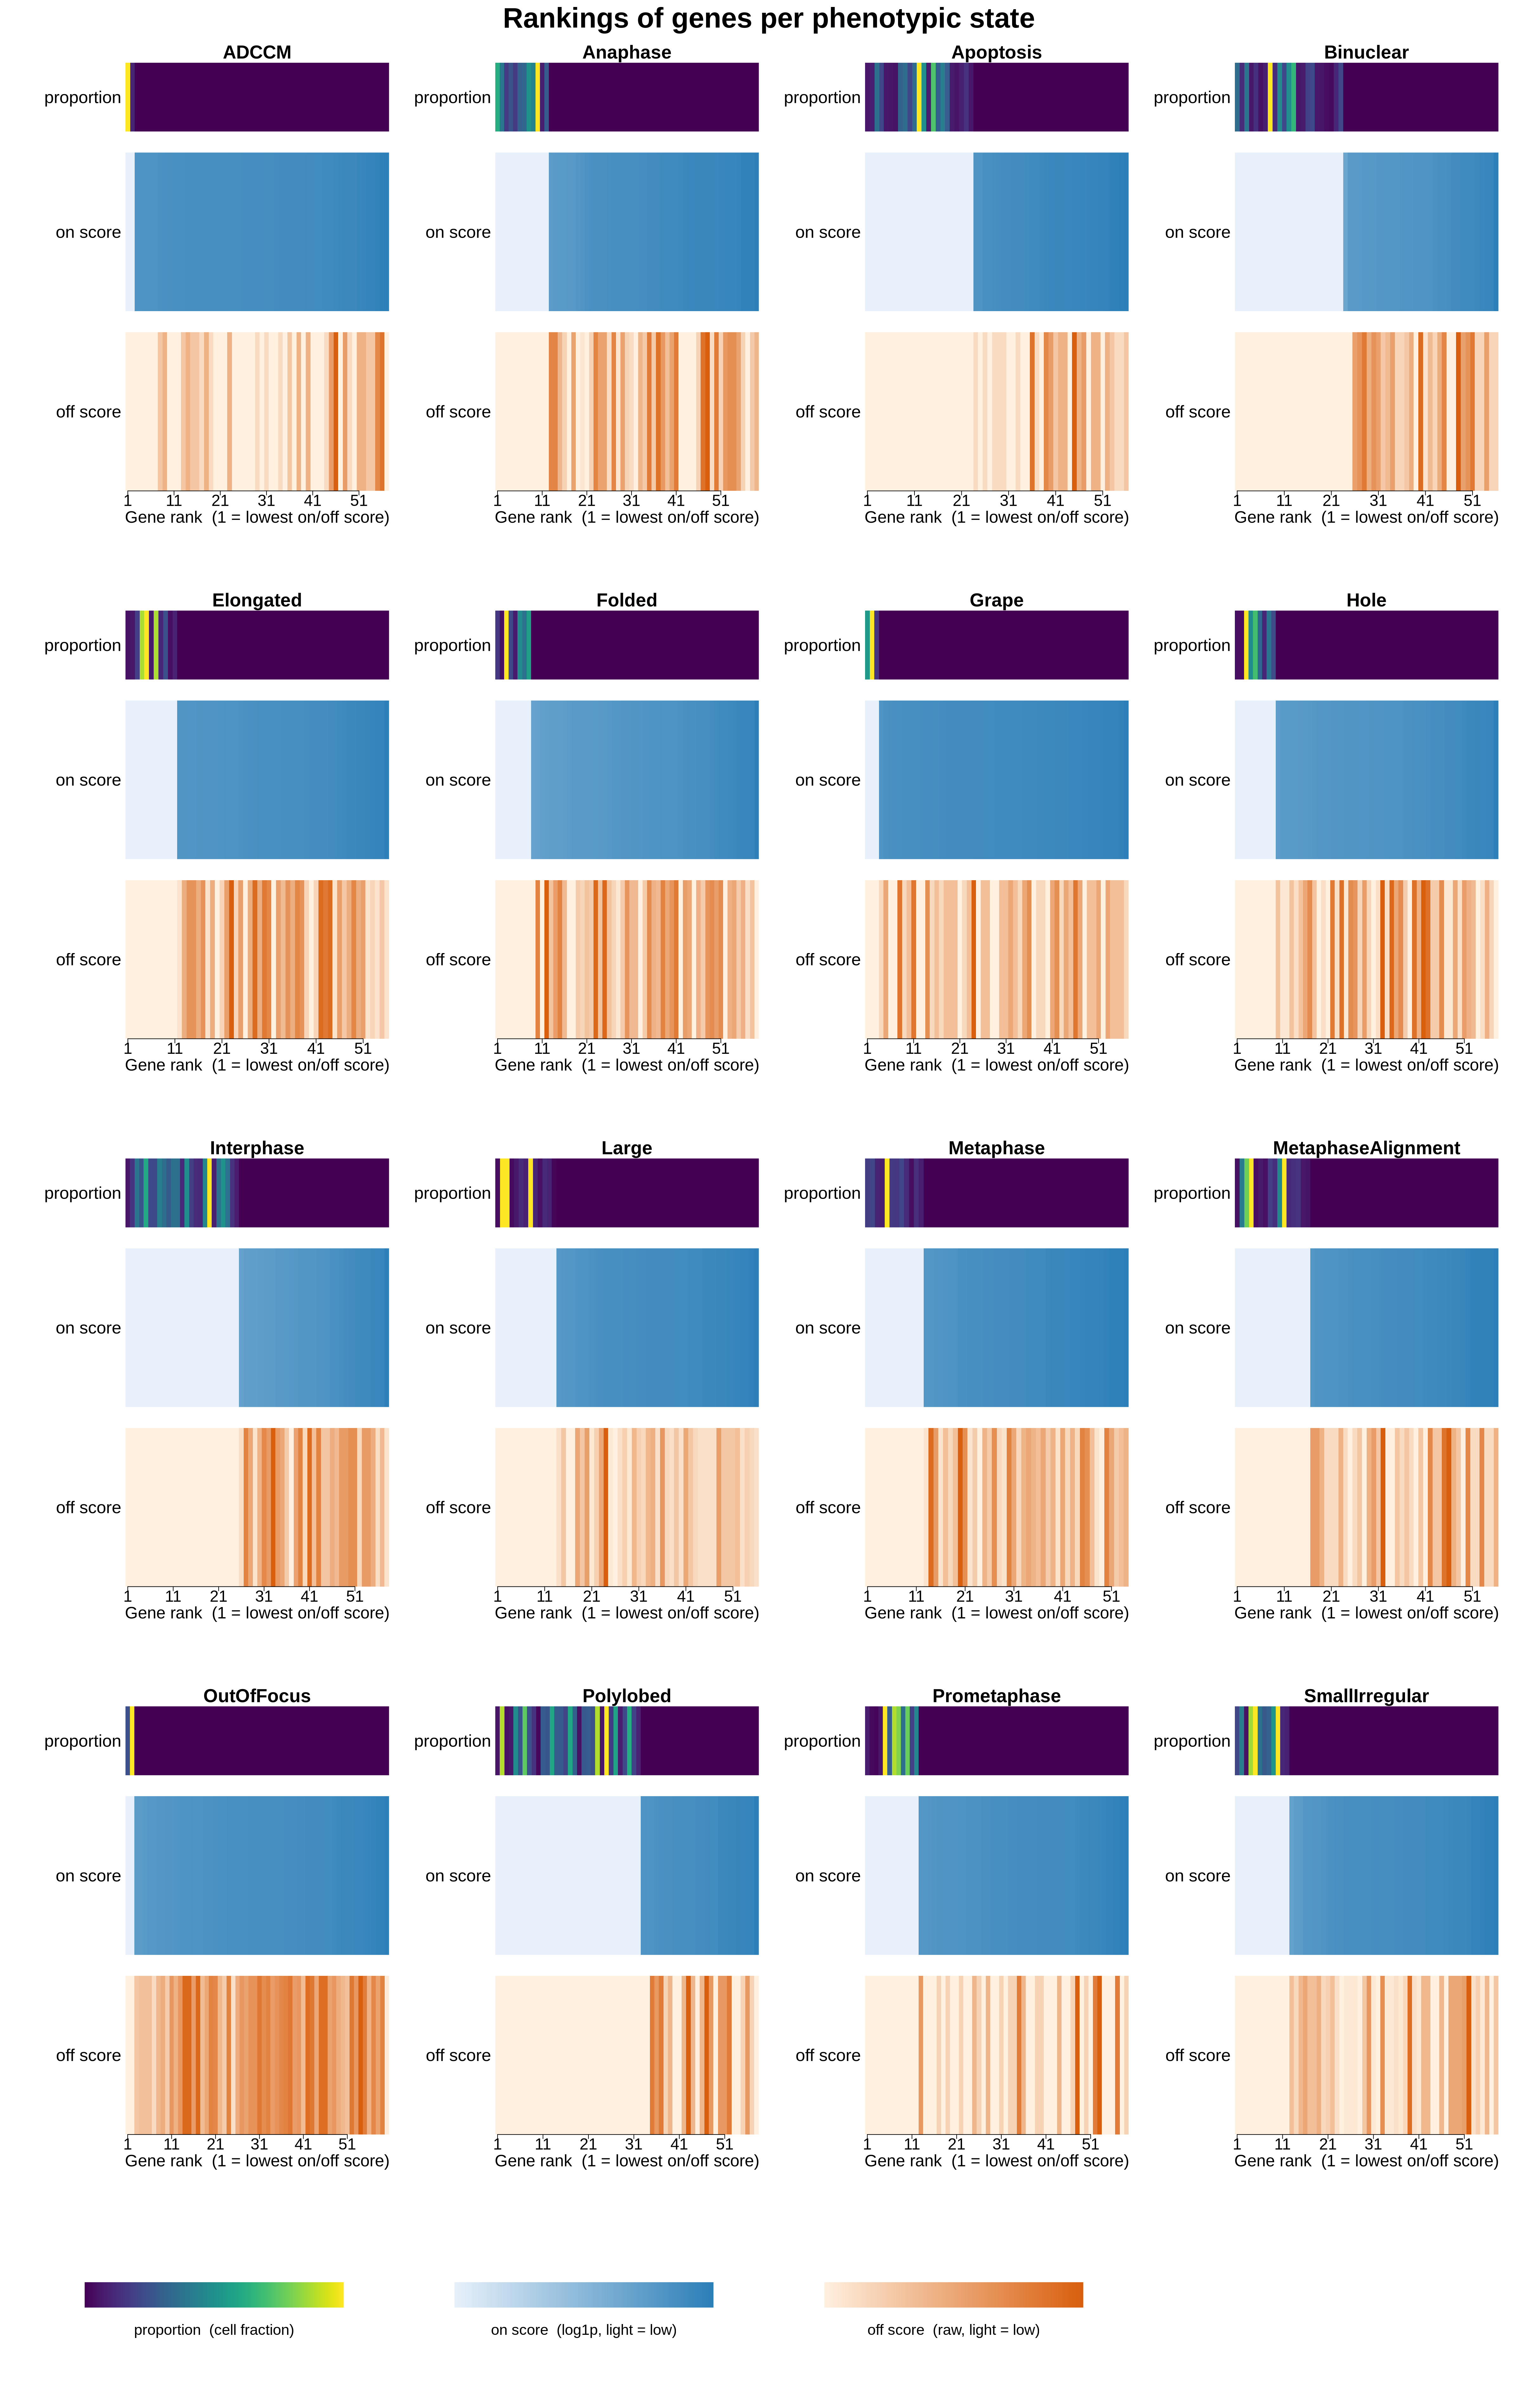

Saved -> /home/erikserrano/Projects/buscar/notebooks/3.mitocheck-analysis/plots/all-plots/heatmap/gene_rankings_phenotypic_state.png


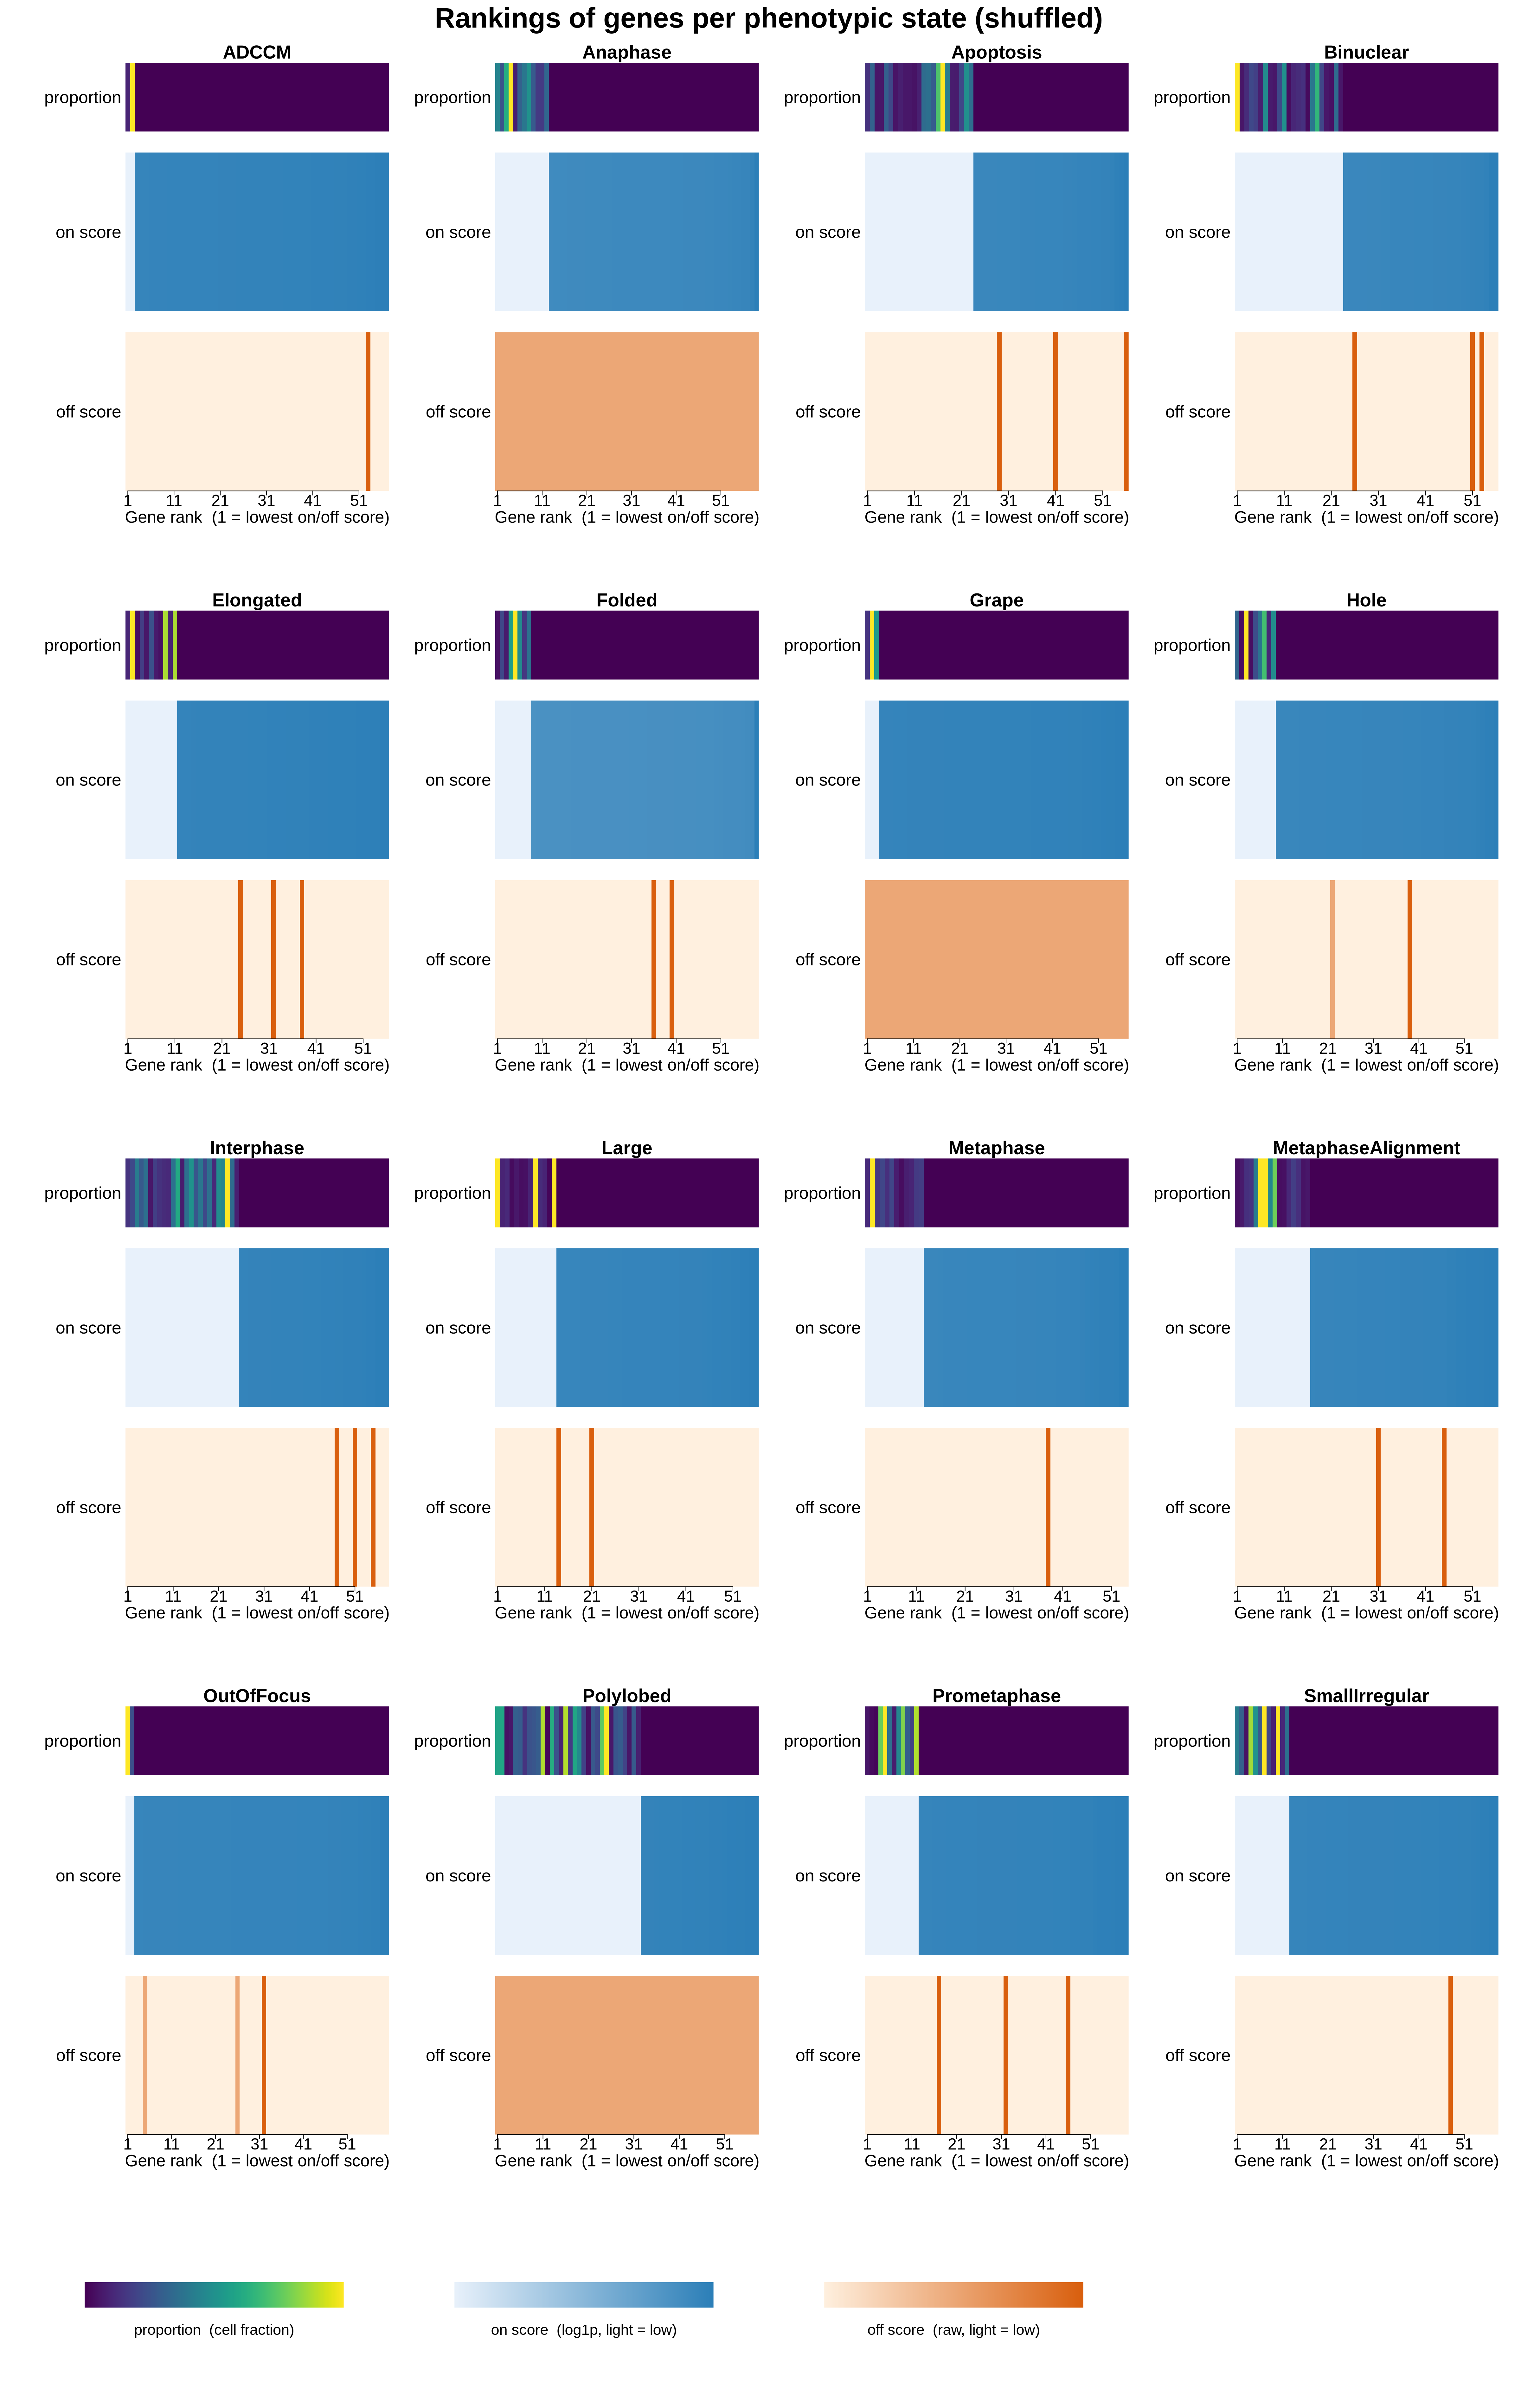

Saved -> /home/erikserrano/Projects/buscar/notebooks/3.mitocheck-analysis/plots/all-plots/heatmap/shuffled_gene_rankings_phenotypic_state.png


In [10]:
# setting plot parameters and color pallete
NCOLS <- 4
NROWS <- ceiling(n_profiles / NCOLS)

CMAP_PROP <- viridis
CMAP_ON <- colorRampPalette(c('#e8f1fb', '#2c7fb8'))
CMAP_OFF <- colorRampPalette(c('#fff0df', '#d95f0e'))

draw_centered_colorbar <- function(cmap_fun, label) {
  par(mar = c(0.6, 0.6, 0.6, 0.6))
  plot.new()
  plot.window(xlim = c(0, 1), ylim = c(0, 1), xaxs = 'i', yaxs = 'i')
  bar_raster <- as.raster(matrix(cmap_fun(256), nrow = 1))
  rasterImage(bar_raster, xleft = 0.14, ybottom = 0.42, xright = 0.86, ytop = 0.68, interpolate = FALSE)
  text(0.5, 0.18, labels = label, cex = 2.14)
}

draw_gene_rankings <- function(input_df, title = 'Rankings of genes per phenotypic state') {
  input_profiles <- sort(unique(input_df$ref_profile))
  n_rows <- ceiling(length(input_profiles) / NCOLS)

  n_main_rows <- n_rows * 4
  layout_mat <- matrix(0, nrow = n_main_rows + 1, ncol = NCOLS)
  panel_idx <- 1

  for (idx in seq_along(input_profiles)) {
    row <- ((idx - 1) %/% NCOLS)
    col <- ((idx - 1) %% NCOLS) + 1
    r0 <- row * 4 + 1
    layout_mat[r0, col] <- panel_idx; panel_idx <- panel_idx + 1
    layout_mat[r0 + 1, col] <- panel_idx; panel_idx <- panel_idx + 1
    layout_mat[r0 + 2, col] <- panel_idx; panel_idx <- panel_idx + 1
    # r0 + 3 is intentionally left as spacer
  }

  prop_bar_panel <- panel_idx; panel_idx <- panel_idx + 1
  on_bar_panel   <- panel_idx; panel_idx <- panel_idx + 1
  off_bar_panel  <- panel_idx; panel_idx <- panel_idx + 1
  layout_mat[n_main_rows + 1, 1] <- prop_bar_panel
  layout_mat[n_main_rows + 1, 2] <- on_bar_panel
  layout_mat[n_main_rows + 1, 3] <- off_bar_panel

  layout(layout_mat, heights = c(rep(c(0.50, 1, 1, 0.55), n_rows), 0.60))
  par(bg = 'white', oma = c(6.5, 3.5, 6.5, 1.5), mar = c(1.5, 11.5, 1.0, 1.2), xpd = NA)

  for (profile in input_profiles) {
    sub <- input_df %>% filter(ref_profile == profile) %>% head(60)
    n_genes <- nrow(sub)
    if (n_genes == 0) {
      plot.new(); plot.new(); plot.new()
      next
    }

    on_scores   <- sub$on_score
    off_scores  <- sub$off_score
    proportions <- if ('proportion' %in% names(sub)) sub$proportion else rep(1, n_genes)
    on_log      <- log1p(on_scores)

    image(x = seq_len(n_genes), y = 1, z = matrix(proportions, ncol = 1),
          col = CMAP_PROP(256), axes = FALSE, xlab = '', ylab = '')
    axis(2, at = 1, labels = 'proportion', las = 1, tick = FALSE, cex.axis = 2.46, line = -0.50)
    title(main = profile, cex.main = 2.66, font.main = 2, line = 0.5)

    image(x = seq_len(n_genes), y = 1, z = matrix(on_log, ncol = 1),
          col = CMAP_ON(256), axes = FALSE, xlab = '', ylab = '')
    axis(2, at = 1, labels = 'on score', las = 1, tick = FALSE, cex.axis = 2.46, line = -0.50)

    image(x = seq_len(n_genes), y = 1, z = matrix(off_scores, ncol = 1),
          col = CMAP_OFF(256), axes = FALSE, xlab = '', ylab = '')
    axis(2, at = 1, labels = 'off score', las = 1, tick = FALSE, cex.axis = 2.46, line = -0.50)
    x_ticks <- seq(1, n_genes, by = 10)
    axis(1, at = x_ticks, labels = x_ticks, cex.axis = 2.28)
    mtext('Gene rank  (1 = lowest on/off score)', side = 1, line = 3.0, cex = 1.57)
  }

  mtext(title, side = 3, outer = TRUE, line = 3.0, cex = 2.66, font = 2)

  draw_centered_colorbar(CMAP_PROP, 'proportion  (cell fraction)')
  draw_centered_colorbar(CMAP_ON,   'on score  (log1p, light = low)')
  draw_centered_colorbar(CMAP_OFF,  'off score  (raw, light = low)')
}

render_and_display <- function(input_df, out_path, title) {
  n_rows <- ceiling(length(unique(input_df$ref_profile)) / NCOLS)
  png(out_path, width = 24, height = n_rows * 9.5, units = 'in', res = 200)
  draw_gene_rankings(input_df, title)
  dev.off()
  cat(sprintf('Saved -> %s\n', out_path))
  if (requireNamespace('IRdisplay', quietly = TRUE)) {
    IRdisplay::display_png(file = out_path)
  } else if (requireNamespace('knitr', quietly = TRUE)) {
    print(knitr::include_graphics(out_path))
  }
}

# ── Original ──────────────────────────────────────────────────────────────────
render_and_display(
  df,
  file.path(output_dir, 'gene_rankings_phenotypic_state.png'),
  'Rankings of genes per phenotypic state'
)

# ── Shuffled ──────────────────────────────────────────────────────────────────
render_and_display(
  shuf_df,
  file.path(output_dir, 'shuffled_gene_rankings_phenotypic_state.png'),
  'Rankings of genes per phenotypic state (shuffled)'
)